In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/Muhammad Dawood/OneDrive/Documents/Tekkdev/Tweets.csv")
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,5.703060e+17,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2/24/2015 11:35,NaN,Eastern Time (US & Canada)
1,5.703010e+17,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2/24/2015 11:15,NaN,Pacific Time (US & Canada)
2,5.703010e+17,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2/24/2015 11:15,Lets Play,Central Time (US & Canada)
3,5.703010e+17,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2/24/2015 11:15,NaN,Pacific Time (US & Canada)
4,5.703010e+17,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2/24/2015 11:14,NaN,Pacific Time (US & Canada)


In [3]:
df_updated = df.copy()
df_updated.shape

(14640, 15)

In [4]:
duplicate_count = df_updated.duplicated().sum()
print(duplicate_count)

36


In [5]:
df_updated.dtypes

tweet_id                        float64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                       str
dtype: object

In [6]:
df_updated.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [7]:
# Clean the dataset

df_updated.columns = [c.strip().lower() for c in df.columns]

df_updated['text'] =df_updated['text'].astype(str).str.strip()
df_updated['text'] = df_updated['text'].replace({'': np.nan})
df_updated['airline_sentiment'] = df_updated['airline_sentiment'].astype(str).str.strip().str.lower()
df_updated['airline'] = df_updated['airline'].astype(str).str.strip()
df_updated['retweet_count'] = pd.to_numeric(df_updated['retweet_count'], errors='coerce').fillna(0).astype(int)
df_updated['airline_sentiment_confidence'] = pd.to_numeric(df_updated['airline_sentiment_confidence'], errors='coerce')
df_updated['airline_sentiment_confidence'] = df_updated['airline_sentiment_confidence'].fillna(df_updated['airline_sentiment_confidence'].median())
df_updated['negativereason_confidence'] = pd.to_numeric(df_updated['negativereason_confidence'], errors='coerce').fillna(0.0)
df_updated['tweet_created'] = pd.to_datetime(df_updated['tweet_created'], errors='coerce')
df_updated['negativereason'] = df_updated['negativereason'].replace({'': np.nan, 'nan': np.nan})
df_updated['negativereason'] = df_updated['negativereason'].fillna('No reason')

df_updated = df_updated[~df_updated['text'].str.lower().str.startswith('rt', na=False)]
df_updated = df_updated.drop_duplicates()

df_updated = df_updated.drop(columns=[c for c in ['airline_sentiment_gold', 'negativereason_gold', 'tweet_coord', 'tweet_id','name','tweet_location','user_timezone'] if c in df.columns], errors='ignore')
df_updated.reset_index(drop=True, inplace=True)

df_updated['tweet_length'] = df_updated['text'].str.len()

print('Shape after cleaning:', df_updated.shape)
print(df_updated[['airline_sentiment', 'airline', 'text', 'retweet_count', 'tweet_length']].head().to_string(index=False))

Shape after cleaning: (14600, 9)
airline_sentiment        airline                                                                                                                           text  retweet_count  tweet_length
          neutral Virgin America                                                                                            @VirginAmerica What @dhepburn said.              0            35
         positive Virgin America                                                       @VirginAmerica plus you've added commercials to the experience... tacky.              0            72
          neutral Virgin America                                                        @VirginAmerica I didn't today... Must mean I need to take another trip!              0            71
         negative Virgin America @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse              0           126
         negative Virg

In [8]:
df_updated.isnull().sum()

airline_sentiment               0
airline_sentiment_confidence    0
negativereason                  0
negativereason_confidence       0
airline                         0
retweet_count                   0
text                            0
tweet_created                   0
tweet_length                    0
dtype: int64

In [9]:
df_updated

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,retweet_count,text,tweet_created,tweet_length
0,neutral,1.0000,No reason,0.0000,Virgin America,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:00,35
1,positive,0.3486,No reason,0.0000,Virgin America,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:00,72
2,neutral,0.6837,No reason,0.0000,Virgin America,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:00,71
3,negative,1.0000,Bad Flight,0.7033,Virgin America,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:00,126
4,negative,1.0000,Can't Tell,1.0000,Virgin America,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:00,55
...,...,...,...,...,...,...,...,...,...
14595,positive,0.3487,No reason,0.0000,American,0,@AmericanAir thank you we got on a different f...,2015-02-22 12:01:00,63
14596,negative,1.0000,Customer Service Issue,1.0000,American,0,@AmericanAir leaving over 20 minutes Late Flig...,2015-02-22 11:59:00,150
14597,neutral,1.0000,No reason,0.0000,American,0,@AmericanAir Please bring American Airlines to...,2015-02-22 11:59:00,60
14598,negative,1.0000,Customer Service Issue,0.6659,American,0,"@AmericanAir you have my money, you change my ...",2015-02-22 11:59:00,135


EDA

Class Distribution

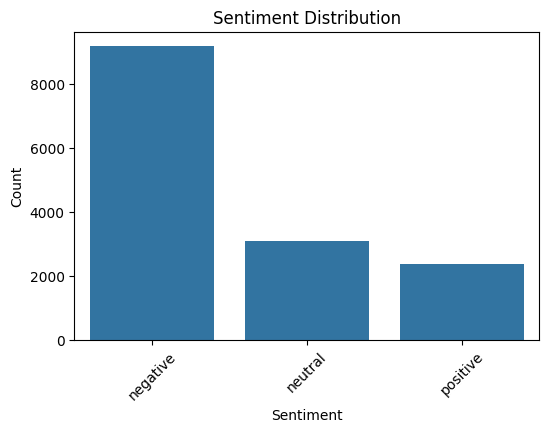

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_updated, x='airline_sentiment', order=df_updated['airline_sentiment'].value_counts().index)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Tweet length distribution

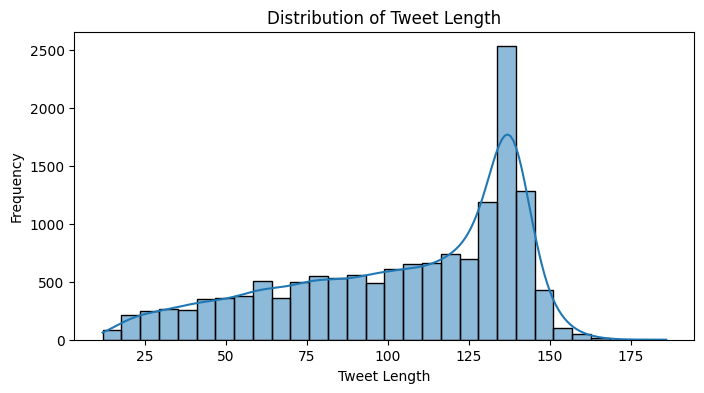

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df_updated['tweet_length'], bins=30, kde=True)
plt.title('Distribution of Tweet Length')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.show()

Airline breakdown

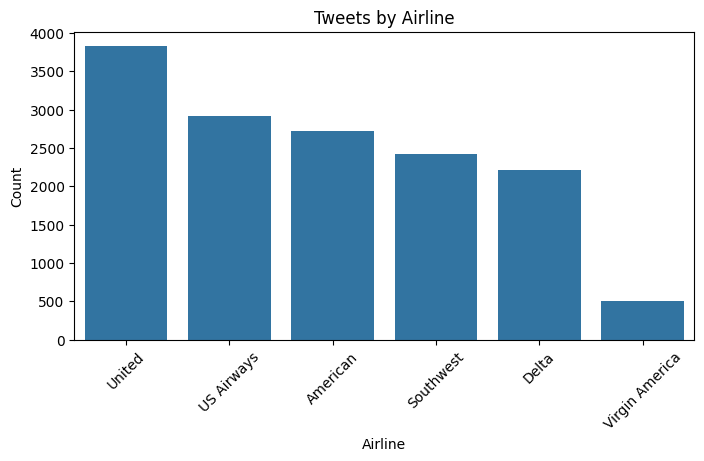

In [12]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_updated, x='airline', order=df_updated['airline'].value_counts().index)
plt.title('Tweets by Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Sentiment by airline

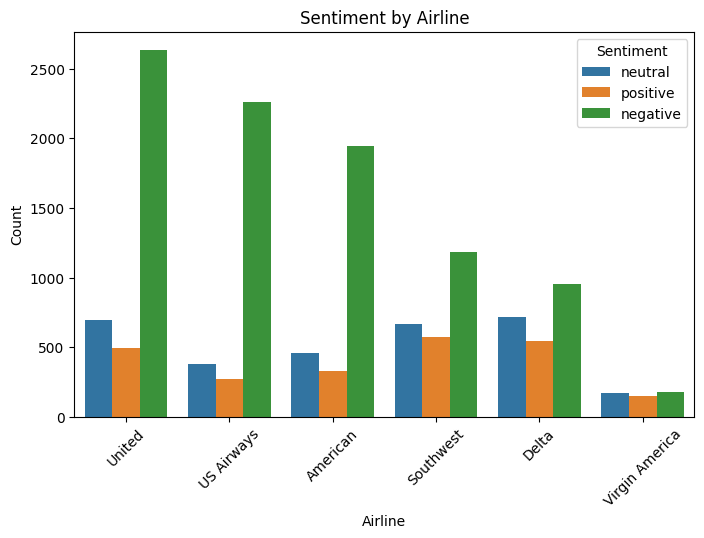

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_updated, x='airline', hue='airline_sentiment', order=df_updated['airline'].value_counts().index)
plt.title('Sentiment by Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()

Negative Reasons

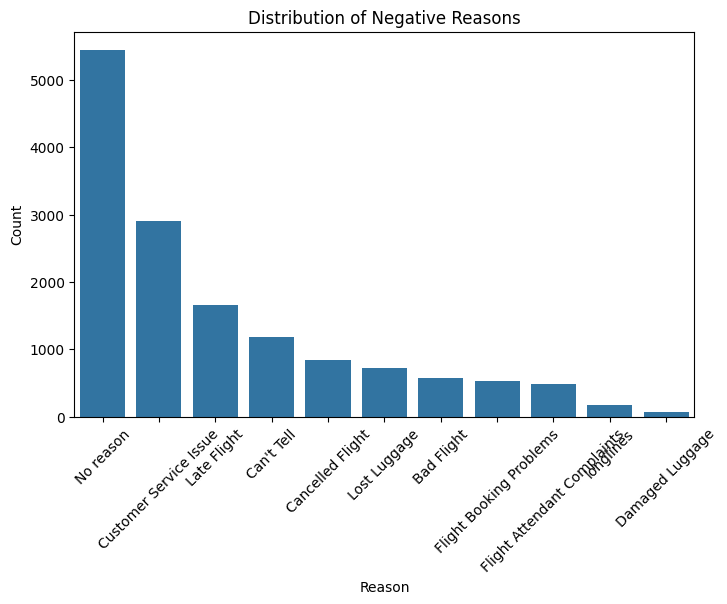

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_updated, x='negativereason', order=df_updated['negativereason'].value_counts().index)
plt.title('Distribution of Negative Reasons')
plt.xlabel('Reason')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [15]:
df_updated.to_csv("clean_tweets.csv", index=False)